In [84]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score


In [91]:
df=pd.read_csv('HousePrice.csv')
df.drop('Id',inplace=True,axis=1)
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [92]:
df['Location']=df['Location'].astype(str)
df['Condition']=df['Condition'].astype(str)
df['Garage']=df['Garage'].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Area       2000 non-null   int64 
 1   Bedrooms   2000 non-null   int64 
 2   Bathrooms  2000 non-null   int64 
 3   Floors     2000 non-null   int64 
 4   YearBuilt  2000 non-null   int64 
 5   Location   2000 non-null   object
 6   Condition  2000 non-null   object
 7   Garage     2000 non-null   object
 8   Price      2000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 140.8+ KB


In [94]:
x=df.drop('Price',axis=1)
y=df['Price']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=43)

preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', ['Area','Bedrooms','Bathrooms','Floors','YearBuilt']),
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         ['Location','Condition','Garage'])
    ]
)

pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=43,
        n_jobs=-1
    ))
])

pipe.fit(x_train,y_train)
pred=pipe.predict(x_test)
print('R2 Score',np.round(r2_score(y_test,pred),2))



R2 Score -0.1


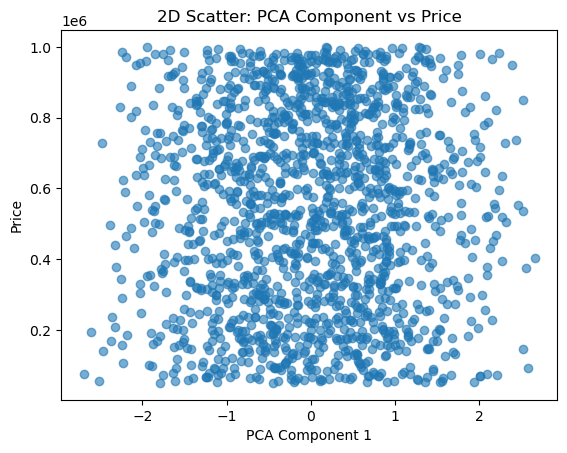

In [73]:
X_train_pca = pipe.named_steps['pca'].transform(
    pipe.named_steps['step'].transform(x_train)
)

plt.scatter(X_train_pca[:, 1], y_train, alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("Price")
plt.title("2D Scatter: PCA Component vs Price")
plt.show()


Text(0.5, 0.92, '3D Scatter: PCA Components vs Price')

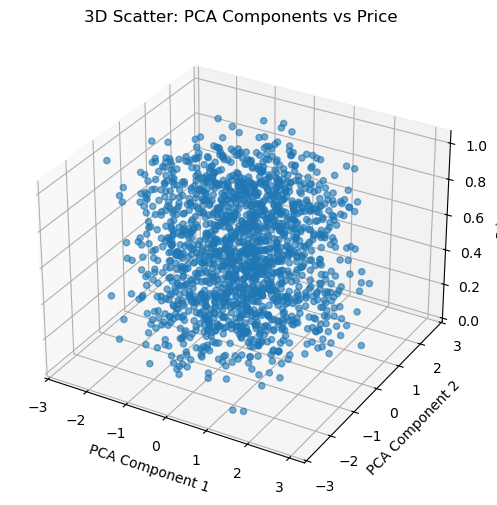

In [72]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    y_train,
    alpha=0.6
)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("Price")
ax.set_title("3D Scatter: PCA Components vs Price")